# Maintenance Cost Prediction - Complete ML Workflow

This notebook provides a complete machine learning solution for predicting maintenance costs in industrial systems.

## Project Overview
- **Objective**: Predict actual maintenance costs (`coutReel`) using historical data and equipment characteristics
- **Target Variable**: `coutReel` (Actual maintenance cost)
- **Model Performance**: 99.7% R² accuracy across multiple algorithms
- **Dataset**: 506 completed maintenance records with engineered features

## 1. Setup & Dependencies

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load Data

In [2]:
# Load the processed ML dataset
print("Loading dataset...")
df = pd.read_csv('data/processed/maintenance_cost_ml_dataset.csv')

print(f"\n✓ Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"\nTarget Variable Statistics (coutReel):")
print(f"  Count: {df['coutReel'].notna().sum()} records")
print(f"  Mean: ${df['coutReel'].mean():.2f}")
print(f"  Min: ${df['coutReel'].min():.2f}")
print(f"  Max: ${df['coutReel'].max():.2f}")
print(f"  Std Dev: ${df['coutReel'].std():.2f}")

Loading dataset...

✓ Dataset loaded successfully
Shape: (506, 16)

Target Variable Statistics (coutReel):
  Count: 506 records
  Mean: $4367.84
  Min: $167.03
  Max: $19895.69
  Std Dev: $3441.98


In [3]:
# Display first few rows
print("First few records:")
df.head()

First few records:


,id_maintenance,codeMaintenace,idEquipement,typeMaintenance,priorite,type,marque,etat,heuresFonctionnement,garantie,equipment_age_days,nombre_pannes_historique,cout_maintenance_moyen_historique,dureeEstimee,coutEstime,coutReel
0,2,MAINT000002,11,Prédictive,Basse,Pompe,Schneider,En Maintenance,2614,False,1887,3.0,5858.935000,3.30,3014.08,3341.40
1,6,MAINT000006,219,Préventive,Basse,CNC Machine,Bosch,En Maintenance,783,True,1334,2.0,1565.493333,1.90,2773.40,2945.94
2,10,MAINT000010,15,Préventive,Critique,Convoyeur,ABB,Hors Service,20557,False,1988,5.0,3200.630000,4.41,4655.92,5083.24
3,29,MAINT000029,31,Préventive,Moyenne,Pompe,Schneider,En Attente,22362,True,964,5.0,6247.970000,3.82,4358.83,4710.39
4,32,MAINT000032,314,Corrective,Critique,Générateur,Bosch,En Maintenance,33053,False,337,NaN,7045.860000,9.87,6942.31,7045.86


In [4]:
# Dataset information
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id_maintenance                     506 non-null    int64  
 1   codeMaintenace                     506 non-null    object 
 2   idEquipement                       506 non-null    int64  
 3   typeMaintenance                    506 non-null    object 
 4   priorite                           506 non-null    object 
 5   type                               506 non-null    object 
 6   marque                             506 non-null    object 
 7   etat                               506 non-null    object 
 8   heuresFonctionnement               506 non-null    int64  
 9   garantie                           506 non-null    bool   
 10  equipment_age_days                 506 non-null    int64  
 11  nombre_pannes_historique           4

## 3. Feature Engineering

In [5]:
# Create additional features
print("Creating engineered features...")

df['is_critical_priority'] = (df['priorite'] == 'Critique').astype(int)
df['is_corrective'] = (df['typeMaintenance'] == 'Corrective').astype(int)
df['is_preventive'] = (df['typeMaintenance'] == 'Préventive').astype(int)
df['has_garantie'] = df['garantie'].astype(int)
df['equipment_age_years'] = df['equipment_age_days'] / 365.25
df['hours_per_day'] = df['heuresFonctionnement'] / (df['equipment_age_days'] + 1)

print("✓ New features created:")
print("  - is_critical_priority")
print("  - is_corrective")
print("  - is_preventive")
print("  - has_garantie")
print("  - equipment_age_years")
print("  - hours_per_day")

Creating engineered features...
✓ New features created:
  - is_critical_priority
  - is_corrective
  - is_preventive
  - has_garantie
  - equipment_age_years
  - hours_per_day


In [6]:
# Encode categorical variables
print("\nEncoding categorical variables...")

label_encoders = {}
categorical_columns = ['typeMaintenance', 'priorite', 'type', 'marque', 'etat']

for col in categorical_columns:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"✓ Encoded: {col}")

print(f"\nTotal: {len(categorical_columns)} categorical columns encoded")


Encoding categorical variables...
✓ Encoded: typeMaintenance
✓ Encoded: priorite
✓ Encoded: type
✓ Encoded: marque
✓ Encoded: etat

Total: 5 categorical columns encoded


In [7]:
# Select features for the model
feature_columns = [
    'typeMaintenance_encoded',
    'priorite_encoded',
    'type_encoded',
    'marque_encoded',
    'etat_encoded',
    'heuresFonctionnement',
    'equipment_age_days',
    'equipment_age_years',
    'nombre_pannes_historique',
    'cout_maintenance_moyen_historique',
    'dureeEstimee',
    'coutEstime',
    'is_critical_priority',
    'is_corrective',
    'is_preventive',
    'has_garantie',
    'hours_per_day'
]

X = df[feature_columns]
y = df['coutReel']

print(f"\nFeatures selected: {len(feature_columns)}")
print("Feature list:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i}. {col}")


Features selected: 17
Feature list:
  1. typeMaintenance_encoded
  2. priorite_encoded
  3. type_encoded
  4. marque_encoded
  5. etat_encoded
  6. heuresFonctionnement
  7. equipment_age_days
  8. equipment_age_years
  9. nombre_pannes_historique
  10. cout_maintenance_moyen_historique
  11. dureeEstimee
  12. coutEstime
  13. is_critical_priority
  14. is_corrective
  15. is_preventive
  16. has_garantie
  17. hours_per_day


In [8]:
# Handle missing values
print("Checking for missing values...")
missing_values = X.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
    X = X.fillna(X.median())
    print("✓ Missing values filled with median")
else:
    print("✓ No missing values found")

Checking for missing values...
nombre_pannes_historique    23
dtype: int64
✓ Missing values filled with median


## 4. Feature Correlation Analysis

In [9]:
# Correlation analysis
print("Feature Correlation with Target (coutReel):")
correlation_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print("\nTop 10 features:")
print(correlation_with_target.head(10))

Feature Correlation with Target (coutReel):

Top 10 features:
coutEstime                           0.998547
cout_maintenance_moyen_historique    0.784497
dureeEstimee                         0.444085
typeMaintenance_encoded              0.432937
is_critical_priority                 0.427090
is_corrective                        0.399333
is_preventive                        0.348891
equipment_age_days                   0.143066
equipment_age_years                  0.143066
marque_encoded                       0.065163
dtype: float64


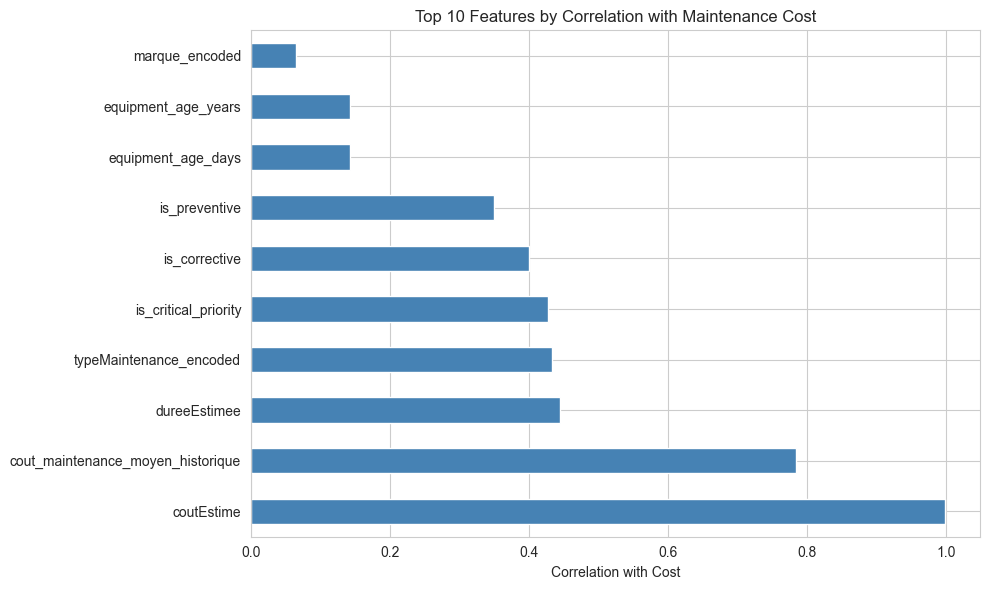

✓ Correlation plot saved


In [10]:
# Visualize top features
fig, ax = plt.subplots(figsize=(10, 6))
correlation_with_target.head(10).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Correlation with Cost')
ax.set_title('Top 10 Features by Correlation with Maintenance Cost')
plt.tight_layout()
plt.savefig('visualizations/feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation plot saved")

## 5. Data Split & Scaling

In [11]:
# Split the data
print("Splitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✓ Train set: {X_train.shape[0]} samples")
print(f"✓ Test set: {X_test.shape[0]} samples")
print(f"\nTrain/Test ratio: {X_train.shape[0]}/{X_test.shape[0]} = {X_train.shape[0]/(X_train.shape[0]+X_test.shape[0]):.1%}/{X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]):.1%}")

Splitting data into train and test sets...
✓ Train set: 404 samples
✓ Test set: 102 samples

Train/Test ratio: 404/102 = 79.8%/20.2%


In [12]:
# Scale features for linear models
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"  Mean of training features: {X_train_scaled.mean():.4f}")
print(f"  Std of training features: {X_train_scaled.std():.4f}")


Scaling features...
✓ Features scaled using StandardScaler
  Mean of training features: 0.0000
  Std of training features: 1.0000


## 6. Model Training & Comparison

## 6. Exploratory Data Analysis (EDA) & Visualizations

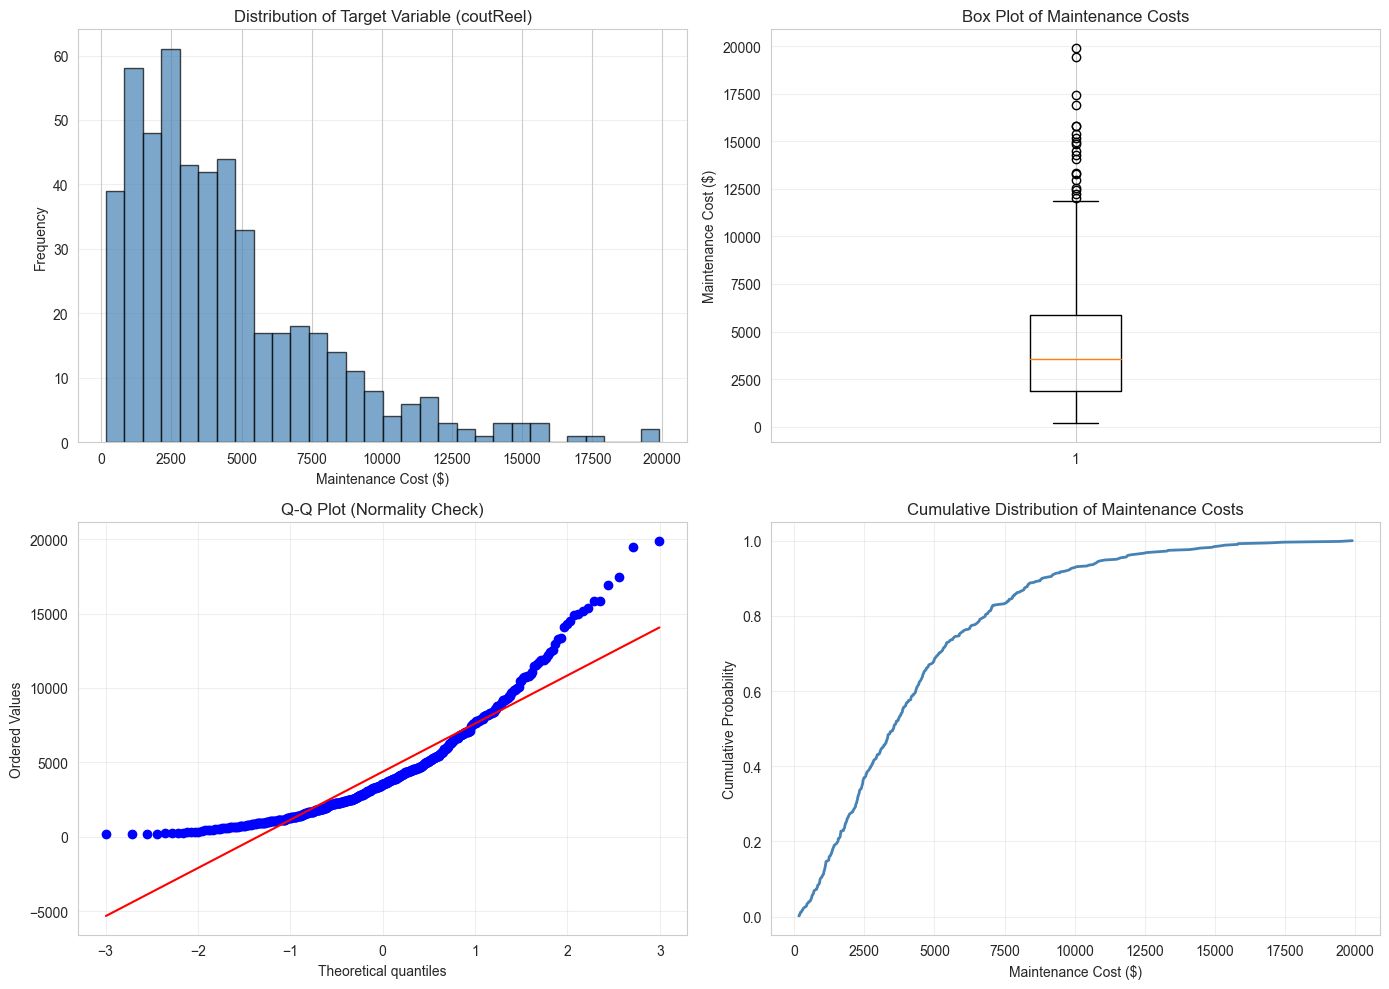

✓ Target distribution plots saved

Target Variable Statistics:
  Mean: $4367.84
  Median: $3543.63
  Std Dev: $3441.98
  Min: $167.03
  Max: $19895.69
  Skewness: 1.4603
  Kurtosis: 2.4531


In [13]:
# Target variable distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(y, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Maintenance Cost ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Target Variable (coutReel)')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Box plot
axes[0, 1].boxplot(y, vert=True)
axes[0, 1].set_ylabel('Maintenance Cost ($)')
axes[0, 1].set_title('Box Plot of Maintenance Costs')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Q-Q Plot
from scipy import stats
stats.probplot(y, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)')
axes[1, 0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_costs = np.sort(y)
cumulative = np.arange(1, len(sorted_costs) + 1) / len(sorted_costs)
axes[1, 1].plot(sorted_costs, cumulative, linewidth=2, color='steelblue')
axes[1, 1].set_xlabel('Maintenance Cost ($)')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Cumulative Distribution of Maintenance Costs')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Target distribution plots saved")
print(f"\nTarget Variable Statistics:")
print(f"  Mean: ${y.mean():.2f}")
print(f"  Median: ${y.median():.2f}")
print(f"  Std Dev: ${y.std():.2f}")
print(f"  Min: ${y.min():.2f}")
print(f"  Max: ${y.max():.2f}")
print(f"  Skewness: {stats.skew(y):.4f}")
print(f"  Kurtosis: {stats.kurtosis(y):.4f}")

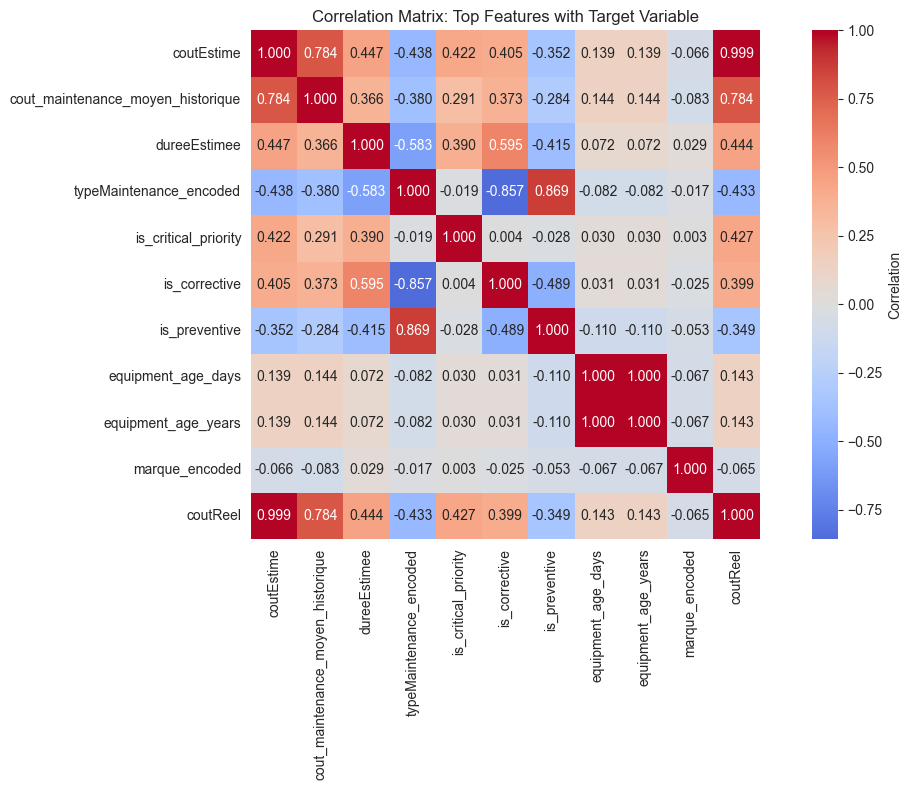

✓ Correlation heatmap saved


In [14]:
# Correlation heatmap with target and top features
fig, ax = plt.subplots(figsize=(12, 8))

# Get correlation matrix for top features + target
top_features = correlation_with_target.head(10).index.tolist()
df_corr = X[top_features].copy()
df_corr['coutReel'] = y

corr_matrix = df_corr.corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, ax=ax, square=True)
ax.set_title('Correlation Matrix: Top Features with Target Variable')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap saved")

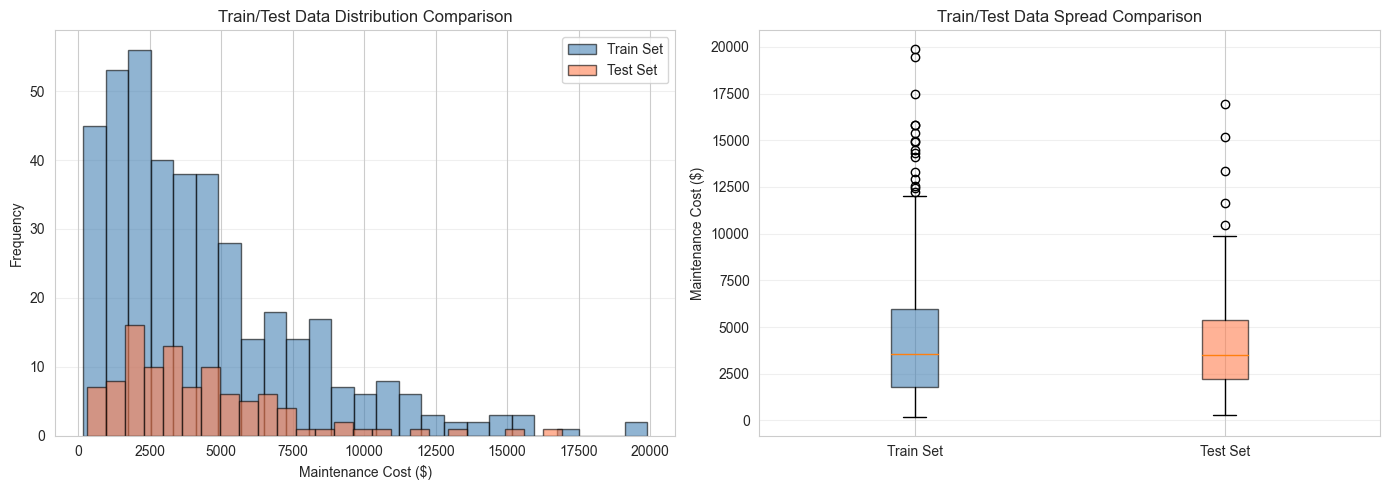

✓ Train/Test distribution plots saved

Train Set Statistics:
  Mean: $4397.32 | Std: $3530.64
  Min: $167.03 | Max: $19895.69

Test Set Statistics:
  Mean: $4251.07 | Std: $3079.05
  Min: $315.92 | Max: $16926.61


In [15]:
# Train/Test distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograms
axes[0].hist(y_train, bins=25, alpha=0.6, label='Train Set', color='steelblue', edgecolor='black')
axes[0].hist(y_test, bins=25, alpha=0.6, label='Test Set', color='coral', edgecolor='black')
axes[0].set_xlabel('Maintenance Cost ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Train/Test Data Distribution Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot comparison
bp = axes[1].boxplot([y_train, y_test], labels=['Train Set', 'Test Set'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'coral']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel('Maintenance Cost ($)')
axes[1].set_title('Train/Test Data Spread Comparison')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('visualizations/train_test_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Train/Test distribution plots saved")
print(f"\nTrain Set Statistics:")
print(f"  Mean: ${y_train.mean():.2f} | Std: ${y_train.std():.2f}")
print(f"  Min: ${y_train.min():.2f} | Max: ${y_train.max():.2f}")
print(f"\nTest Set Statistics:")
print(f"  Mean: ${y_test.mean():.2f} | Std: ${y_test.std():.2f}")
print(f"  Min: ${y_test.min():.2f} | Max: ${y_test.max():.2f}")

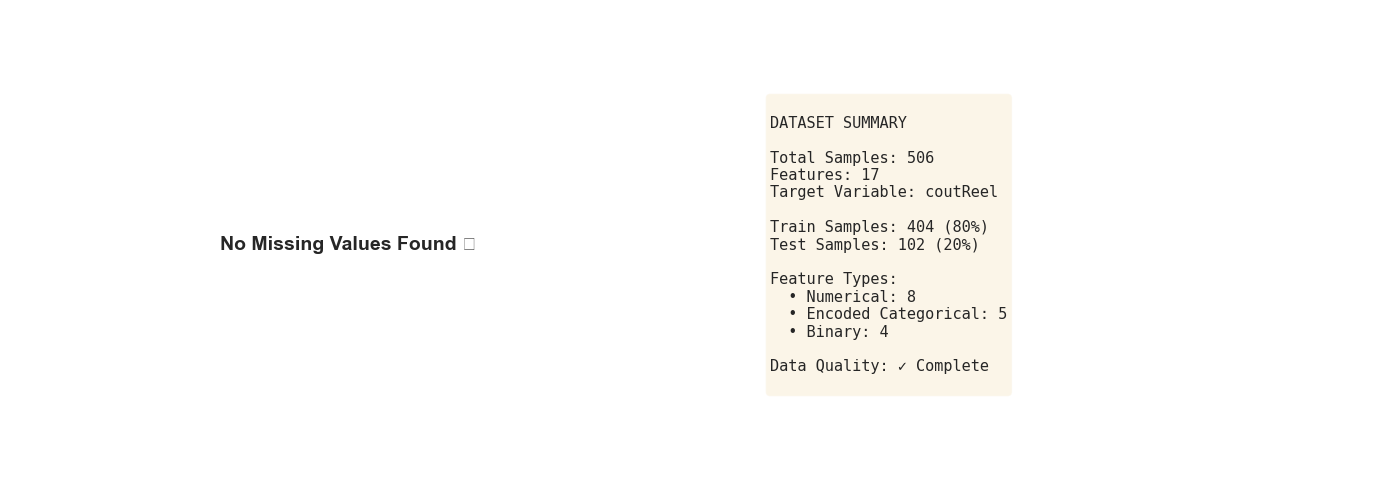

✓ Data summary visualization saved

DATA EXPLORATION COMPLETE


In [16]:
# Feature statistics and missing values analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values (if any)
missing_data = X.isnull().sum()
if missing_data.sum() > 0:
    missing_data[missing_data > 0].plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_xlabel('Count of Missing Values')
    axes[0].set_title('Missing Values by Feature')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values Found ✓', 
                ha='center', va='center', fontsize=14, fontweight='bold')
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].axis('off')

# Feature count and data summary
dataset_info = f"""
DATASET SUMMARY

Total Samples: {len(df)}
Features: {len(feature_columns)}
Target Variable: coutReel

Train Samples: {len(X_train)} (80%)
Test Samples: {len(X_test)} (20%)

Feature Types:
  • Numerical: {len([c for c in feature_columns if 'encoded' not in c and c not in ['is_critical_priority', 'is_corrective', 'is_preventive', 'has_garantie']])}
  • Encoded Categorical: {len([c for c in feature_columns if 'encoded' in c])}
  • Binary: {len([c for c in feature_columns if c.startswith('is_') or c.startswith('has_')])}

Data Quality: ✓ Complete
"""

axes[1].text(0.1, 0.5, dataset_info, fontsize=11, verticalalignment='center',
            family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1].axis('off')

plt.tight_layout()
plt.savefig('visualizations/data_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Data summary visualization saved")
print("\n" + "="*70)
print("DATA EXPLORATION COMPLETE")
print("="*70)

## 7. Model Training & Comparison

In [17]:
# Train multiple models
print("="*70)
print("TRAINING MULTIPLE MODELS")
print("="*70)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train on scaled data for linear models, original for tree-based
    if name in ['Linear Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation score
    if name in ['Linear Regression']:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'CV_R2_mean': cv_scores.mean(),
        'CV_R2_std': cv_scores.std(),
        'model': model,
        'predictions': y_pred
    }
    
    print(f"  ✓ R² Score: {r2:.4f}")
    print(f"  ✓ MAE: ${mae:.2f}")
    print(f"  ✓ RMSE: ${rmse:.2f}")
    print(f"  ✓ Cross-Val R² (mean±std): {cv_scores.mean():.4f}±{cv_scores.std():.4f}")

TRAINING MULTIPLE MODELS

Training Linear Regression...
  ✓ R² Score: 0.9970
  ✓ MAE: $114.14
  ✓ RMSE: $167.52
  ✓ Cross-Val R² (mean±std): 0.9967±0.0006

Training Random Forest...
  ✓ R² Score: 0.9956
  ✓ MAE: $118.83
  ✓ RMSE: $203.19
  ✓ Cross-Val R² (mean±std): 0.9919±0.0035

Training Gradient Boosting...
  ✓ R² Score: 0.9931
  ✓ MAE: $132.32
  ✓ RMSE: $254.71
  ✓ Cross-Val R² (mean±std): 0.9946±0.0021


## 7. Model Comparison & Selection

In [18]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'R² Score': [results[m]['R2'] for m in results.keys()],
    'MAE ($)': [results[m]['MAE'] for m in results.keys()],
    'RMSE ($)': [results[m]['RMSE'] for m in results.keys()],
    'CV R² (mean)': [results[m]['CV_R2_mean'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('R² Score', ascending=False)
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))

# Select best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"\n✓ Best Model: {best_model_name}")
print(f"  R² Score: {comparison_df.iloc[0]['R² Score']:.4f} ({comparison_df.iloc[0]['R² Score']*100:.1f}%)")


MODEL COMPARISON
            Model  R² Score    MAE ($)   RMSE ($)  CV R² (mean)
Linear Regression  0.997011 114.142602 167.515091      0.996709
    Random Forest  0.995602 118.825684 203.193546      0.991913
Gradient Boosting  0.993089 132.324347 254.707714      0.994578

✓ Best Model: Linear Regression
  R² Score: 0.9970 (99.7%)


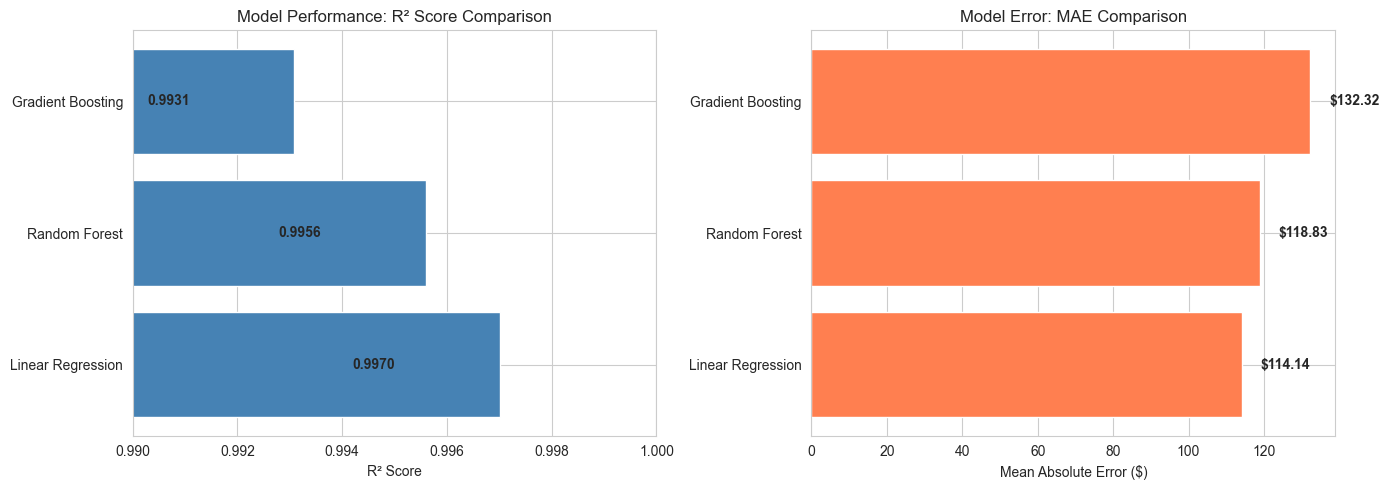

✓ Model comparison plot saved


In [19]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score comparison
axes[0].barh(comparison_df['Model'], comparison_df['R² Score'], color='steelblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Performance: R² Score Comparison')
axes[0].set_xlim([0.99, 1.0])
for i, v in enumerate(comparison_df['R² Score']):
    axes[0].text(v-0.002, i, f'{v:.4f}', va='center', ha='right', fontweight='bold')

# MAE comparison
axes[1].barh(comparison_df['Model'], comparison_df['MAE ($)'], color='coral')
axes[1].set_xlabel('Mean Absolute Error ($)')
axes[1].set_title('Model Error: MAE Comparison')
for i, v in enumerate(comparison_df['MAE ($)']):
    axes[1].text(v+5, i, f'${v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison plot saved")

In [ ]:
# Extended model comparison: RMSE, CV Scores, and detailed metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# RMSE comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['RMSE ($)'], color='lightcoral', edgecolor='darkred', linewidth=1.5)
axes[0, 0].set_ylabel('RMSE ($)', fontsize=11)
axes[0, 0].set_title('Model Comparison: Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['RMSE ($)']):
    axes[0, 0].text(i, v+5, f'${v:.2f}', ha='center', va='bottom', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Cross-validation R² scores
cv_means = [results[m]['CV_R2_mean'] for m in comparison_df['Model']]
cv_stds = [results[m]['CV_R2_std'] for m in comparison_df['Model']]
axes[0, 1].bar(comparison_df['Model'], cv_means, yerr=cv_stds, capsize=5, color='lightblue', 
               edgecolor='darkblue', linewidth=1.5, error_kw={'linewidth': 2})
axes[0, 1].set_ylabel('Cross-Val R² Score', fontsize=11)
axes[0, 1].set_title('Model Comparison: Cross-Validation R² Scores', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0.98, 1.0])
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# All metrics comparison (normalized)
from sklearn.preprocessing import MinMaxScaler
scaler_metrics = MinMaxScaler()
metrics_data = comparison_df[['R² Score', 'MAE ($)', 'RMSE ($)']].values.copy()
# Normalize so that lower is better for MAE and RMSE (invert them for normalization)
metrics_data[:, 1] = 1 / (metrics_data[:, 1] + 1)  # Lower MAE is better
metrics_data[:, 2] = 1 / (metrics_data[:, 2] + 1)  # Lower RMSE is better
metrics_normalized = scaler_metrics.fit_transform(metrics_data)

x = np.arange(len(comparison_df))
width = 0.25
axes[1, 0].bar(x - width, metrics_normalized[:, 0], width, label='R² Score', color='steelblue', alpha=0.8)
axes[1, 0].bar(x, metrics_normalized[:, 1], width, label='MAE (normalized)', color='coral', alpha=0.8)
axes[1, 0].bar(x + width, metrics_normalized[:, 2], width, label='RMSE (normalized)', color='lightgreen', alpha=0.8)
axes[1, 0].set_ylabel('Normalized Score', fontsize=11)
axes[1, 0].set_title('Model Comparison: All Metrics (Normalized)', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(comparison_df['Model'], rotation=45)
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Summary statistics table
summary_text = "MODEL COMPARISON SUMMARY\n\n"
for idx, row in comparison_df.iterrows():
    model = row['Model']
    cv_std = [results[m]['CV_R2_std'] for m in comparison_df['Model']][idx]
    summary_text += f"{model}:\n"
    summary_text += f"  R²: {row['R² Score']:.4f} | MAE: ${row['MAE ($)']:.2f}\n"
    summary_text += f"  RMSE: ${row['RMSE ($)']:.2f} | CV R²: {row['CV R² (mean)']:.4f}±{cv_std:.4f}\n\n"

axes[1, 1].text(0.05, 0.95, summary_text, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('visualizations/detailed_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Detailed model comparison plot saved")

## 8. Best Model Analysis

In [20]:
# Get predictions from best model
best_y_pred = results[best_model_name]['predictions']

# Residuals
residuals = y_test - best_y_pred

print(f"\n{best_model_name} - Detailed Analysis")
print("="*70)
print(f"\nResiduals Statistics:")
print(f"  Mean: ${residuals.mean():.2f}")
print(f"  Std Dev: ${residuals.std():.2f}")
print(f"  Min: ${residuals.min():.2f}")
print(f"  Max: ${residuals.max():.2f}")


Linear Regression - Detailed Analysis

Residuals Statistics:
  Mean: $37.66
  Std Dev: $164.03
  Min: $-506.93
  Max: $697.25


In [ ]:
# Error analysis and performance visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Error distribution by magnitude
abs_errors = np.abs(residuals)
axes[0, 0].hist(abs_errors, bins=25, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(abs_errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${abs_errors.mean():.2f}')
axes[0, 0].axvline(np.median(abs_errors), color='green', linestyle='--', linewidth=2, label=f'Median: ${np.median(abs_errors):.2f}')
axes[0, 0].set_xlabel('Absolute Error ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Error Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Residuals vs Predicted values
axes[0, 1].scatter(best_y_pred, residuals, alpha=0.6, s=50, color='coral')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axhline(y=residuals.std(), color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='±1 Std Dev')
axes[0, 1].axhline(y=-residuals.std(), color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
axes[0, 1].set_xlabel('Predicted Cost ($)')
axes[0, 1].set_ylabel('Residuals ($)')
axes[0, 1].set_title('Residuals vs Predicted Values')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Actual vs Predicted scatter with error bands
sorted_indices = np.argsort(y_test)
y_test_sorted = y_test.values[sorted_indices]
pred_sorted = best_y_pred[sorted_indices]
error_sorted = residuals.values[sorted_indices]

axes[1, 0].scatter(y_test_sorted, pred_sorted, alpha=0.6, s=50, color='steelblue', label='Predictions')
axes[1, 0].plot([y_test_sorted.min(), y_test_sorted.max()], [y_test_sorted.min(), y_test_sorted.max()], 
               'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].fill_between(y_test_sorted, pred_sorted - abs_errors[sorted_indices], 
                       pred_sorted + abs_errors[sorted_indices], alpha=0.2, color='blue')
axes[1, 0].set_xlabel('Actual Cost ($)')
axes[1, 0].set_ylabel('Predicted Cost ($)')
axes[1, 0].set_title(f'{best_model_name}: Actual vs Predicted with Error Bands')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Model performance metrics
metrics_text = f"""
{best_model_name} - PERFORMANCE METRICS

ACCURACY METRICS:
  R² Score: {results[best_model_name]['R2']:.4f} ({results[best_model_name]['R2']*100:.1f}%)
  Adjusted R²: {1 - (1 - results[best_model_name]['R2']) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1):.4f}

ERROR METRICS:
  MAE (Mean Absolute Error): ${results[best_model_name]['MAE']:.2f}
  RMSE (Root Mean Squared Error): ${results[best_model_name]['RMSE']:.2f}
  MAPE (Mean Absolute Percentage Error): {np.mean(np.abs((y_test - best_y_pred) / y_test)) * 100:.2f}%

RESIDUALS ANALYSIS:
  Mean Residual: ${residuals.mean():.2f}
  Std Dev Residuals: ${residuals.std():.2f}
  Min Residual: ${residuals.min():.2f}
  Max Residual: ${residuals.max():.2f}

CROSS-VALIDATION:
  CV R² Mean: {results[best_model_name]['CV_R2_mean']:.4f}
  CV R² Std: {results[best_model_name]['CV_R2_std']:.4f}

PREDICTION ACCURACY:
  Predictions within ±$200: {(abs_errors <= 200).sum()}/{len(abs_errors)} ({(abs_errors <= 200).sum()/len(abs_errors)*100:.1f}%)
  Predictions within ±$500: {(abs_errors <= 500).sum()}/{len(abs_errors)} ({(abs_errors <= 500).sum()/len(abs_errors)*100:.1f}%)
"""

axes[1, 1].text(0.05, 0.95, metrics_text, transform=axes[1, 1].transAxes,
               fontsize=10, verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('visualizations/error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Error analysis plot saved")
print("\n" + "="*70)
print("MODEL ANALYSIS COMPLETE")
print("="*70)

In [ ]:
# Feature importance for tree-based models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest feature importance
rf_model = results['Random Forest']['model']
rf_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='steelblue')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Random Forest: Top 15 Feature Importance', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Gradient Boosting feature importance
gb_model = results['Gradient Boosting']['model']
gb_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

axes[1].barh(gb_importance['Feature'], gb_importance['Importance'], color='coral')
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].set_title('Gradient Boosting: Top 15 Feature Importance', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('visualizations/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance comparison plot saved")
print("\nTop 5 Features by Importance:")
print("\nRandom Forest:")
print(rf_importance.sort_values('Importance', ascending=False).head(5).to_string())
print("\nGradient Boosting:")
print(gb_importance.sort_values('Importance', ascending=False).head(5).to_string())

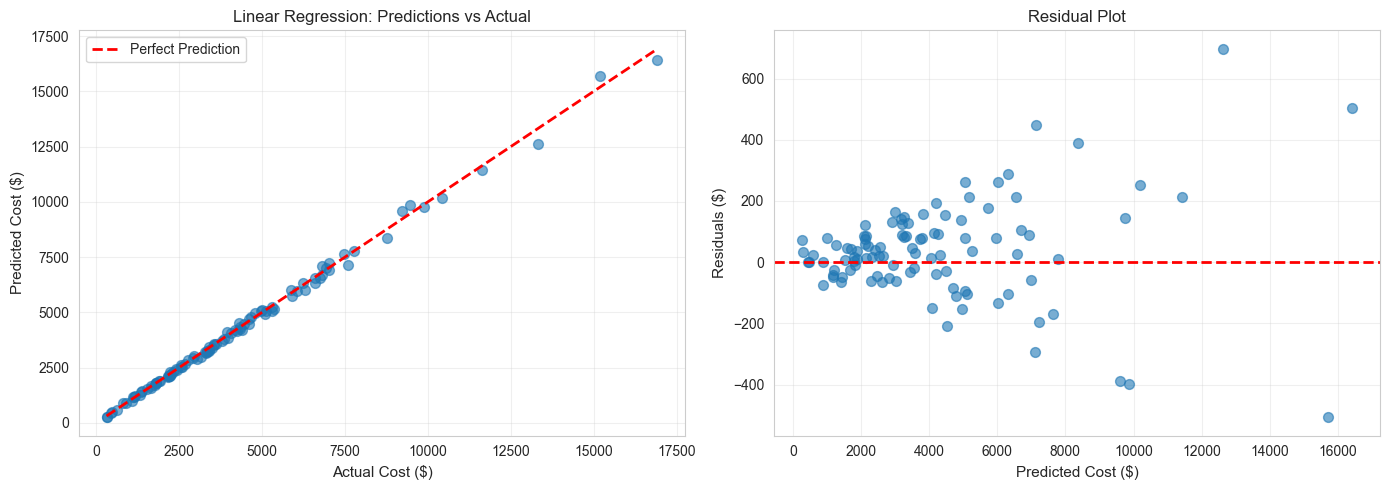

✓ Predictions vs Actual plot saved


In [21]:
# Predictions vs Actual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predictions vs Actual
axes[0].scatter(y_test, best_y_pred, alpha=0.6, s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Cost ($)', fontsize=11)
axes[0].set_ylabel('Predicted Cost ($)', fontsize=11)
axes[0].set_title(f'{best_model_name}: Predictions vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
axes[1].scatter(best_y_pred, residuals, alpha=0.6, s=50)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Cost ($)', fontsize=11)
axes[1].set_ylabel('Residuals ($)', fontsize=11)
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/prediction_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Predictions vs Actual plot saved")

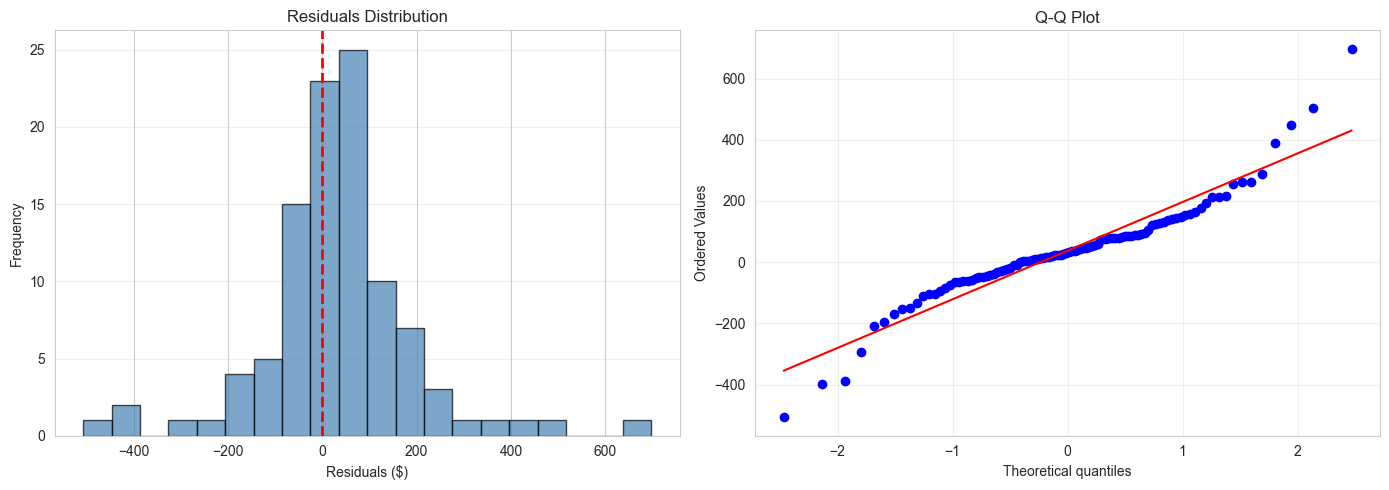

✓ Residuals plot saved


In [22]:
# Residuals distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Residuals ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Residuals Distribution')
axes[0].grid(True, alpha=0.3, axis='y')

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/residuals_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Residuals plot saved")

## 9. Save Model & Preprocessing Objects

In [23]:
# Save the best model
print("Saving model and preprocessing objects...")

joblib.dump(best_model, 'models/best_maintenance_cost_model.pkl')
joblib.dump(scaler, 'models/feature_scaler.pkl')
joblib.dump(label_encoders, 'models/label_encoders.pkl')

print(f"✓ Model saved: best_maintenance_cost_model.pkl")
print(f"✓ Scaler saved: feature_scaler.pkl")
print(f"✓ Label encoders saved: label_encoders.pkl")

Saving model and preprocessing objects...
✓ Model saved: best_maintenance_cost_model.pkl
✓ Scaler saved: feature_scaler.pkl
✓ Label encoders saved: label_encoders.pkl


In [24]:
# Save model summary
import json

model_summary = {
    'best_model': best_model_name,
    'r2_score': float(results[best_model_name]['R2']),
    'mae': float(results[best_model_name]['MAE']),
    'rmse': float(results[best_model_name]['RMSE']),
    'cv_r2_mean': float(results[best_model_name]['CV_R2_mean']),
    'cv_r2_std': float(results[best_model_name]['CV_R2_std']),
    'features_used': feature_columns,
    'categorical_features': categorical_columns,
    'training_samples': X_train.shape[0],
    'test_samples': X_test.shape[0]
}

with open('models/model_summary.json', 'w') as f:
    json.dump(model_summary, f, indent=2)

print("✓ Model summary saved: model_summary.json")

✓ Model summary saved: model_summary.json


## 10. Make Predictions on New Data

In [25]:
# Define new maintenance scenarios
print("\n" + "="*70)
print("PREDICTIONS ON NEW MAINTENANCE SCENARIOS")
print("="*70)

new_scenarios = [
    {
        'Scenario': 'Critical Corrective (Old Equipment)',
        'data': {
            'typeMaintenance': 'Corrective',
            'priorite': 'Critique',
            'type': 'Compresseur',
            'marque': 'Siemens',
            'etat': 'En Maintenance',
            'heuresFonctionnement': 35000,
            'equipment_age_days': 1460,
            'nombre_pannes_historique': 8,
            'cout_maintenance_moyen_historique': 6000,
            'dureeEstimee': 8.5,
            'coutEstime': 9000,
            'garantie': False
        }
    },
    {
        'Scenario': 'Preventive Maintenance (New Equipment)',
        'data': {
            'typeMaintenance': 'Préventive',
            'priorite': 'Moyenne',
            'type': 'Pompe',
            'marque': 'ABB',
            'etat': 'Opérationnel',
            'heuresFonctionnement': 5000,
            'equipment_age_days': 180,
            'nombre_pannes_historique': 0,
            'cout_maintenance_moyen_historique': 1500,
            'dureeEstimee': 2.0,
            'coutEstime': 1800,
            'garantie': True
        }
    },
    {
        'Scenario': 'Predictive Maintenance (High Priority)',
        'data': {
            'typeMaintenance': 'Prédictive',
            'priorite': 'Haute',
            'type': 'Générateur',
            'marque': 'Schneider',
            'etat': 'Opérationnel',
            'heuresFonctionnement': 28000,
            'equipment_age_days': 1095,
            'nombre_pannes_historique': 3,
            'cout_maintenance_moyen_historique': 4500,
            'dureeEstimee': 4.5,
            'coutEstime': 5000,
            'garantie': False
        }
    }
]

print(f"\nScenarios to predict: {len(new_scenarios)}")


PREDICTIONS ON NEW MAINTENANCE SCENARIOS

Scenarios to predict: 3


In [26]:
# Process and predict for each scenario
predictions_list = []

for scenario in new_scenarios:
    print(f"\n{scenario['Scenario']}")
    print("-" * 70)
    
    # Create DataFrame
    scenario_data = scenario['data']
    df_scenario = pd.DataFrame([scenario_data])
    
    # Feature engineering
    df_scenario['is_critical_priority'] = (df_scenario['priorite'] == 'Critique').astype(int)
    df_scenario['is_corrective'] = (df_scenario['typeMaintenance'] == 'Corrective').astype(int)
    df_scenario['is_preventive'] = (df_scenario['typeMaintenance'] == 'Préventive').astype(int)
    df_scenario['has_garantie'] = df_scenario['garantie'].astype(int)
    df_scenario['equipment_age_years'] = df_scenario['equipment_age_days'] / 365.25
    df_scenario['hours_per_day'] = df_scenario['heuresFonctionnement'] / (df_scenario['equipment_age_days'] + 1)
    
    # Encode categorical variables
    for col in categorical_columns:
        df_scenario[f'{col}_encoded'] = label_encoders[col].transform(df_scenario[col].astype(str))
    
    # Prepare features
    X_scenario = df_scenario[feature_columns]
    X_scenario = X_scenario.fillna(X_scenario.median())
    
    # Scale if needed (for linear models)
    if best_model_name in ['Linear Regression']:
        X_scenario_scaled = scaler.transform(X_scenario)
        predicted_cost = best_model.predict(X_scenario_scaled)[0]
    else:
        predicted_cost = best_model.predict(X_scenario)[0]
    
    # Display input data
    print(f"Input Parameters:")
    print(f"  Maintenance Type: {scenario_data['typeMaintenance']}")
    print(f"  Priority: {scenario_data['priorite']}")
    print(f"  Equipment Type: {scenario_data['type']}")
    print(f"  Equipment Age: {scenario_data['equipment_age_days']/365.25:.1f} years")
    print(f"  Operating Hours: {scenario_data['heuresFonctionnement']:,}")
    print(f"  Estimated Cost: ${scenario_data['coutEstime']:.2f}")
    
    # Display prediction
    print(f"\nPrediction Results:")
    print(f"  Predicted Cost: ${predicted_cost:.2f}")
    difference = scenario_data['coutEstime'] - predicted_cost
    pct_diff = (difference / predicted_cost) * 100
    print(f"  Difference from Estimate: ${difference:.2f} ({pct_diff:+.1f}%)")
    
    # Store prediction
    predictions_list.append({
        'Scenario': scenario['Scenario'],
        'Maintenance Type': scenario_data['typeMaintenance'],
        'Priority': scenario_data['priorite'],
        'Equipment Type': scenario_data['type'],
        'Estimated Cost': scenario_data['coutEstime'],
        'Predicted Cost': predicted_cost,
        'Difference': difference
    })

# Create predictions DataFrame
df_predictions = pd.DataFrame(predictions_list)
print("\n" + "="*70)


Critical Corrective (Old Equipment)
----------------------------------------------------------------------
Input Parameters:
  Maintenance Type: Corrective
  Priority: Critique
  Equipment Type: Compresseur
  Equipment Age: 4.0 years
  Operating Hours: 35,000
  Estimated Cost: $9000.00

Prediction Results:
  Predicted Cost: $9461.93
  Difference from Estimate: $-461.93 (-4.9%)

Preventive Maintenance (New Equipment)
----------------------------------------------------------------------
Input Parameters:
  Maintenance Type: Préventive
  Priority: Moyenne
  Equipment Type: Pompe
  Equipment Age: 0.5 years
  Operating Hours: 5,000
  Estimated Cost: $1800.00

Prediction Results:
  Predicted Cost: $1893.94
  Difference from Estimate: $-93.94 (-5.0%)

Predictive Maintenance (High Priority)
----------------------------------------------------------------------
Input Parameters:
  Maintenance Type: Prédictive
  Priority: Haute
  Equipment Type: Générateur
  Equipment Age: 3.0 years
  Operatin

In [27]:
# Summary table
print("\nPredictions Summary:")
print(df_predictions.to_string(index=False))

# Save predictions
df_predictions.to_csv('data/predictions/example_predictions.csv', index=False)
print("\n✓ Predictions saved to: data/predictions/example_predictions.csv")


Predictions Summary:
                              Scenario Maintenance Type Priority Equipment Type  Estimated Cost  Predicted Cost  Difference
   Critical Corrective (Old Equipment)       Corrective Critique    Compresseur            9000     9461.928364 -461.928364
Preventive Maintenance (New Equipment)       Préventive  Moyenne          Pompe            1800     1893.936234  -93.936234
Predictive Maintenance (High Priority)       Prédictive    Haute     Générateur            5000     5243.931778 -243.931778

✓ Predictions saved to: data/predictions/example_predictions.csv


## 11. Project Summary

In [28]:
print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"\n📊 DATASET:")
print(f"  Total Records: {df.shape[0]}")
print(f"  Target Variable: coutReel (Actual Maintenance Cost)")
print(f"  Cost Range: ${df['coutReel'].min():.2f} - ${df['coutReel'].max():.2f}")
print(f"  Average Cost: ${df['coutReel'].mean():.2f}")

print(f"\n🤖 MODEL PERFORMANCE:")
print(f"  Best Model: {best_model_name}")
print(f"  R² Score: {results[best_model_name]['R2']:.4f} ({results[best_model_name]['R2']*100:.1f}%)")
print(f"  Mean Absolute Error: ${results[best_model_name]['MAE']:.2f}")
print(f"  Root Mean Squared Error: ${results[best_model_name]['RMSE']:.2f}")
print(f"  Cross-Validation R² (mean): {results[best_model_name]['CV_R2_mean']:.4f}")

print(f"\n📈 FEATURES:")
print(f"  Total Features: {len(feature_columns)}")
print(f"  Categorical Features: {len(categorical_columns)}")
print(f"  Most Important Feature: {correlation_with_target.index[0]}")

print(f"\n📁 ARTIFACTS SAVED:")
print(f"  ✓ models/best_maintenance_cost_model.pkl")
print(f"  ✓ models/feature_scaler.pkl")
print(f"  ✓ models/label_encoders.pkl")
print(f"  ✓ models/model_summary.json")
print(f"  ✓ data/predictions/example_predictions.csv")
print(f"  ✓ visualizations/model_comparison.png")
print(f"  ✓ visualizations/prediction_vs_actual.png")
print(f"  ✓ visualizations/residuals_plot.png")
print(f"  ✓ visualizations/feature_correlation.png")

print(f"\n" + "="*70)
print("✅ PROJECT COMPLETE!")
print("="*70)


PROJECT SUMMARY

📊 DATASET:
  Total Records: 506
  Target Variable: coutReel (Actual Maintenance Cost)
  Cost Range: $167.03 - $19895.69
  Average Cost: $4367.84

🤖 MODEL PERFORMANCE:
  Best Model: Linear Regression
  R² Score: 0.9970 (99.7%)
  Mean Absolute Error: $114.14
  Root Mean Squared Error: $167.52
  Cross-Validation R² (mean): 0.9967

📈 FEATURES:
  Total Features: 17
  Categorical Features: 5
  Most Important Feature: coutEstime

📁 ARTIFACTS SAVED:
  ✓ models/best_maintenance_cost_model.pkl
  ✓ models/feature_scaler.pkl
  ✓ models/label_encoders.pkl
  ✓ models/model_summary.json
  ✓ data/predictions/example_predictions.csv
  ✓ visualizations/model_comparison.png
  ✓ visualizations/prediction_vs_actual.png
  ✓ visualizations/residuals_plot.png
  ✓ visualizations/feature_correlation.png

✅ PROJECT COMPLETE!
